# CEX Benchmark Error Analysis Visualization

This notebook loads and visualizes error analysis results from the CEX benchmark.

**Features:**
- Load analysis results for one or multiple models
- Visualize failure patterns and distributions
- Compare models side-by-side
- Interactive filtering and exploration
- Export publication-ready figures

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 1. Load Data

Load analysis results for one or more models.

In [2]:
# Configuration: Specify which models to analyze
MODEL_NAMES = [
    'mistral_small',  # Primary model for analysis
    # 'qwen',  # Uncomment to compare with other models
    # 'another_model',
]

OUTPUT_DIR = Path('outputs')
TASK_DIR = Path('cex')

def load_model_data(model_name):
    """Load all CSV files for a given model."""
    model_dir = OUTPUT_DIR / model_name
    
    if not model_dir.exists():
        print(f"Warning: Directory not found for {model_name}")
        return None
    
    data = {
        'model_name': model_name,
        'detailed': pd.read_csv(model_dir / 'detailed_failures.csv'),
        'by_task': pd.read_csv(model_dir / 'summary_by_task.csv'),
        'by_category': pd.read_csv(model_dir / 'summary_by_category.csv'),
        'overall': pd.read_csv(model_dir / 'summary_overall.csv'),
    }
    
    return data

# Load data for all specified models
models_data = {}
for model_name in MODEL_NAMES:
    data = load_model_data(model_name)
    if data:
        models_data[model_name] = data
        print(f"✓ Loaded data for {model_name}")

if not models_data:
    raise ValueError("No model data loaded! Make sure to run analyze_errors.py first.")

# Use the first model as the primary one for single-model visualizations
primary_model = list(models_data.keys())[0]
primary_data = models_data[primary_model]

print(f"\nPrimary model for visualization: {primary_model}")
print(f"Total documents analyzed: {len(primary_data['detailed'])}")

✓ Loaded data for mistral_small

Primary model for visualization: mistral_small
Total documents analyzed: 336


## 2. Overall Statistics

In [3]:
# Display overall summary
print(f"Overall Statistics for {primary_model}")
print("="*50)

overall = primary_data['overall']
for _, row in overall.iterrows():
    metric = row['metric']
    value = row['value']
    
    if 'rate' in metric:
        print(f"{metric:.<40} {value:.2%}")
    elif 'count' in metric or 'total' in metric:
        print(f"{metric:.<40} {int(value)}")
    else:
        print(f"{metric:.<40} {value:.2f}")

Overall Statistics for mistral_small
total_documents......................... 336
success_count........................... 117
success_rate............................ 34.82%
structural_error_count.................. 3
structural_error_rate................... 0.89%
refusal_count........................... 0
refusal_rate............................ 0.00%
factual_error_count..................... 216
factual_error_rate...................... 64.29%
total_misclassifications................ 2941
total_hallucinations.................... 387
total_correct_refs...................... 11152
avg_gt_ref_count........................ 46
avg_extracted_ref_count................. 43


## 3. Failure Category Distribution

Visualize the distribution of the three main failure categories.

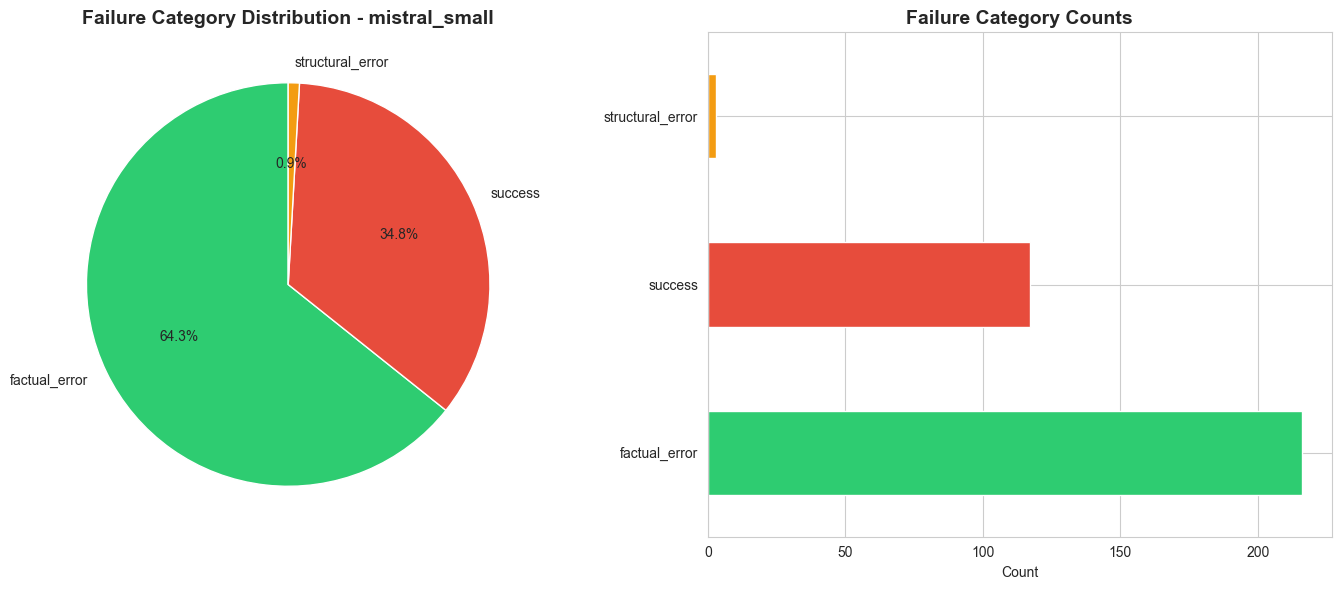


Failure Category Breakdown:
failure_category
factual_error       216
success             117
structural_error      3
Name: count, dtype: int64


In [4]:
# Calculate failure category distribution
detailed = primary_data['detailed']

category_counts = detailed['failure_category'].value_counts()

# Create pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart of failure categories
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
category_counts.plot(
    kind='pie',
    ax=ax1,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
ax1.set_title(f'Failure Category Distribution - {primary_model}', fontsize=14, fontweight='bold')
ax1.set_ylabel('')

# Bar chart for better comparison
category_counts.plot(kind='barh', ax=ax2, color=colors)
ax2.set_title('Failure Category Counts', fontsize=14, fontweight='bold')
ax2.set_xlabel('Count')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / primary_model / 'failure_category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFailure Category Breakdown:")
print(category_counts)

## 4. Minor vs Major Error Analysis

For factual errors, distinguish between minor errors (medium similarity) and major errors (low similarity).

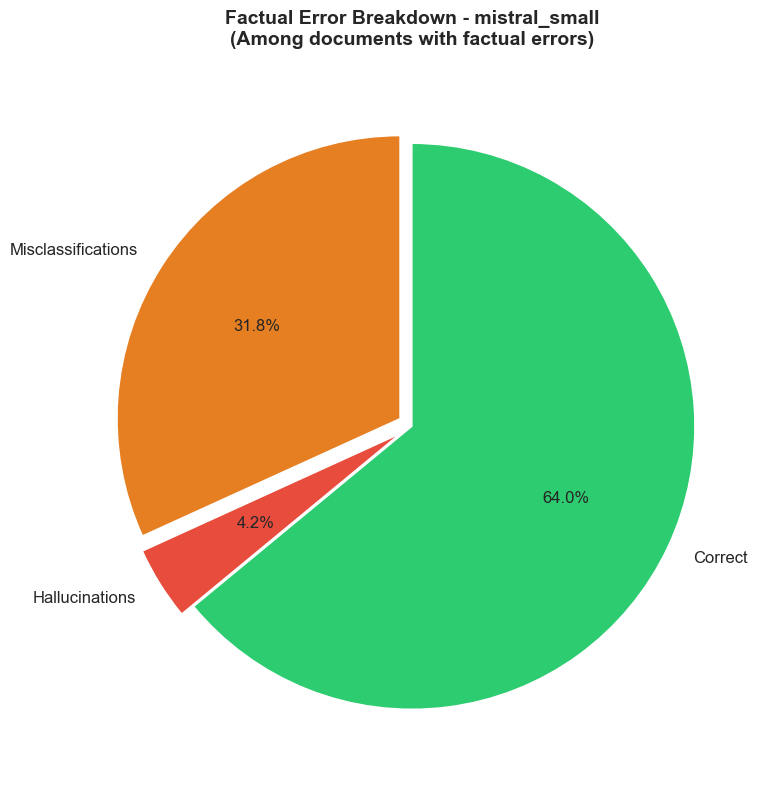


Factual Error Analysis:
Documents with factual errors: 216
Total misclassifications: 2941
Total hallucinations: 387
Total correct extractions: 5920


In [5]:
# Filter to factual errors only
factual_errors = detailed[detailed['has_factual_error'] == True]

if len(factual_errors) > 0:
    total_minor_errors = factual_errors['minor_error_count'].sum()
    total_major_errors = factual_errors['major_error_count'].sum()
    total_correct = factual_errors['correct_count'].sum()
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    labels = ['Minor Errors', 'Major Errors', 'Correct']
    sizes = [total_minor_errors, total_major_errors, total_correct]
    colors = ['#e67e22', '#e74c3c', '#2ecc71']
    explode = (0.05, 0.05, 0)
    
    ax.pie(
        sizes,
        labels=labels,
        autopct='%1.1f%%',
        colors=colors,
        explode=explode,
        startangle=90,
        textprops={'fontsize': 12}
    )
    ax.set_title(
        f'Factual Error Breakdown - {primary_model}\n(Among documents with factual errors)',
        fontsize=14,
        fontweight='bold',
        pad=20
    )
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / primary_model / 'minor_vs_major_errors.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nFactual Error Analysis:")
    print(f"Documents with factual errors: {len(factual_errors)}")
    print(f"Total minor errors: {int(total_minor_errors)}")
    print(f"Total major errors: {int(total_major_errors)}")
    print(f"Total correct extractions: {int(total_correct)}")
else:
    print("No factual errors found in the data.")

## 5. Failure Rates by Document Category

Analyze which document categories have the highest failure rates.

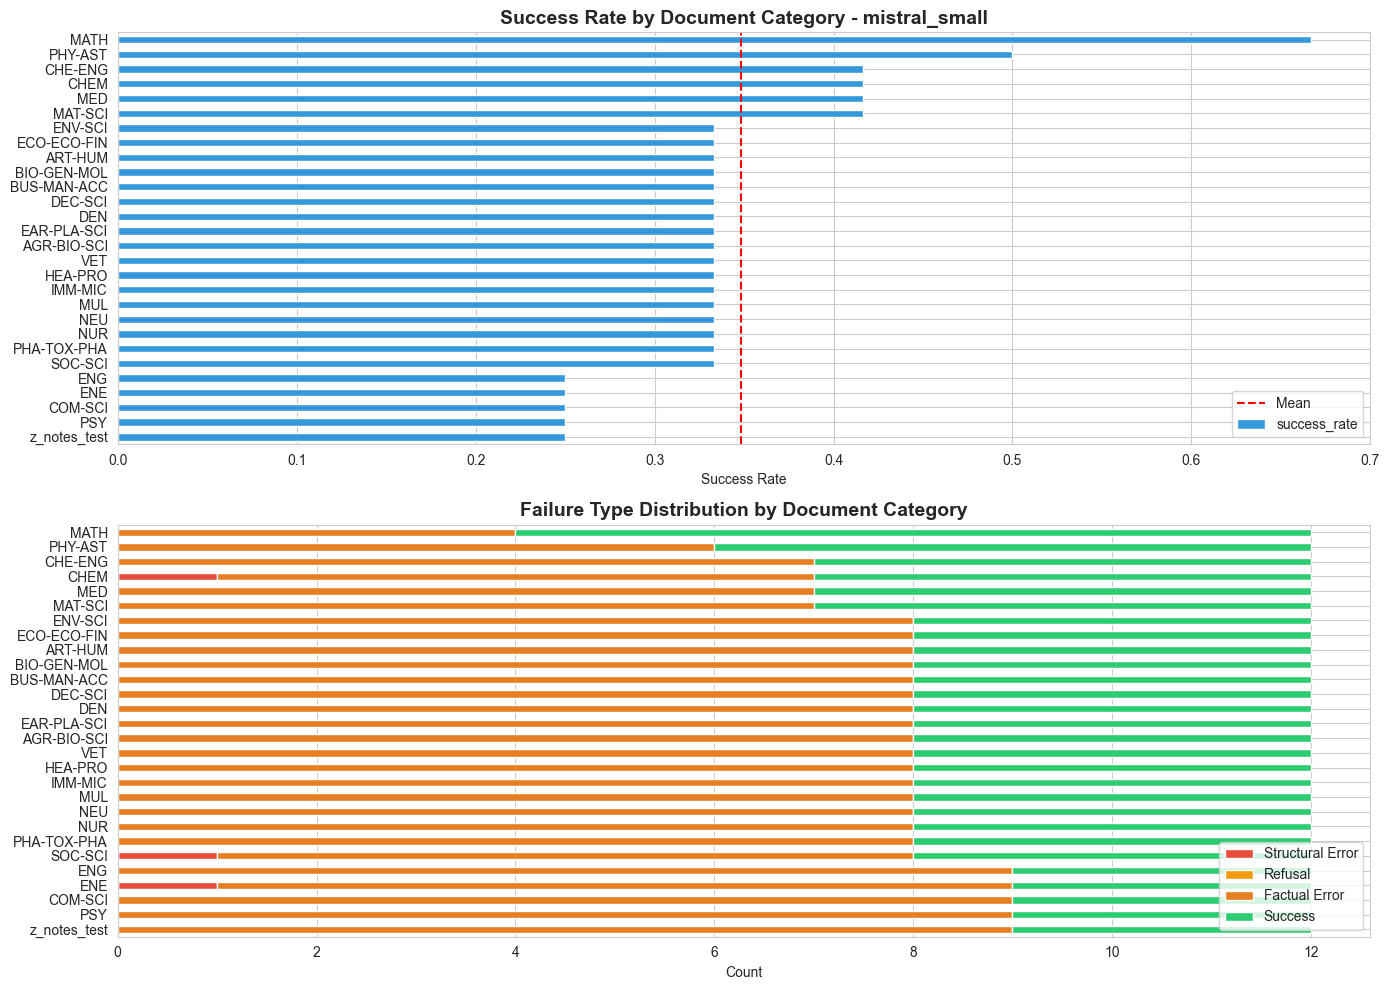


Top 5 categories with lowest success rates:
   document_category  success_rate  total_documents
27      z_notes_test          0.25               12
24               PSY          0.25               12
6            COM-SCI          0.25               12
11               ENE          0.25               12
12               ENG          0.25               12


In [6]:
by_category = primary_data['by_category'].sort_values('success_rate')

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Success rate by category
ax1 = axes[0]
by_category.plot(
    x='document_category',
    y='success_rate',
    kind='barh',
    ax=ax1,
    color='#3498db',
    legend=False
)
ax1.set_title(f'Success Rate by Document Category - {primary_model}', fontsize=14, fontweight='bold')
ax1.set_xlabel('Success Rate')
ax1.set_ylabel('')
ax1.axvline(x=by_category['success_rate'].mean(), color='red', linestyle='--', label='Mean')
ax1.legend()

# Stacked bar chart: failure categories by document category
ax2 = axes[1]

failure_cols = ['structural_error_count', 'refusal_count', 'factual_error_count', 'success_count']
by_category[failure_cols].plot(
    kind='barh',
    stacked=True,
    ax=ax2,
    color=['#e74c3c', '#f39c12', '#e67e22', '#2ecc71']
)
ax2.set_title('Failure Type Distribution by Document Category', fontsize=14, fontweight='bold')
ax2.set_xlabel('Count')
ax2.set_ylabel('')
ax2.set_yticklabels(by_category['document_category'])
ax2.legend([
    'Structural Error',
    'Refusal',
    'Factual Error',
    'Success'
], loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / primary_model / 'failure_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 5 categories with lowest success rates:")
print(by_category[['document_category', 'success_rate', 'total_documents']].head())

## 6. Failure Rates by Task Type

Compare performance across different tasks.

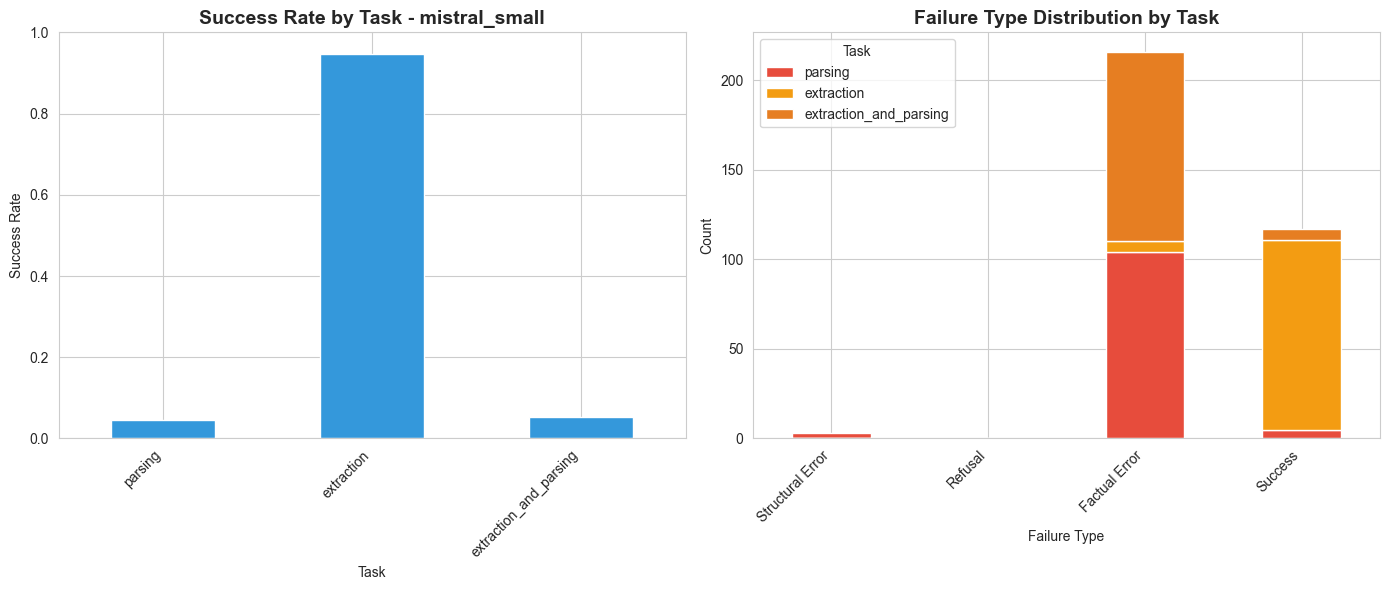


Task Performance Summary:
                     task  success_rate  total_documents
0                 parsing      0.044643              112
1              extraction      0.946429              112
2  extraction_and_parsing      0.053571              112


In [7]:
by_task = primary_data['by_task']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Task success rates
ax1 = axes[0]
by_task.plot(
    x='task',
    y='success_rate',
    kind='bar',
    ax=ax1,
    color='#3498db',
    legend=False
)
ax1.set_title(f'Success Rate by Task - {primary_model}', fontsize=14, fontweight='bold')
ax1.set_xlabel('Task')
ax1.set_ylabel('Success Rate')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylim([0, 1])

# Stacked bar: failure categories by task
ax2 = axes[1]
failure_cols = ['structural_error_count', 'refusal_count', 'factual_error_count', 'success_count']
by_task[failure_cols].T.plot(
    kind='bar',
    stacked=True,
    ax=ax2,
    color=['#e74c3c', '#f39c12', '#e67e22', '#2ecc71']
)
ax2.set_title('Failure Type Distribution by Task', fontsize=14, fontweight='bold')
ax2.set_xlabel('Failure Type')
ax2.set_ylabel('Count')
ax2.set_xticklabels([
    'Structural Error',
    'Refusal',
    'Factual Error',
    'Success'
], rotation=45, ha='right')
ax2.legend(by_task['task'].values, title='Task', loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / primary_model / 'failure_by_task.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTask Performance Summary:")
print(by_task[['task', 'success_rate', 'total_documents']])

## 7. Heatmap: Failure Category × Task Type

Visualize the relationship between failure categories and tasks.

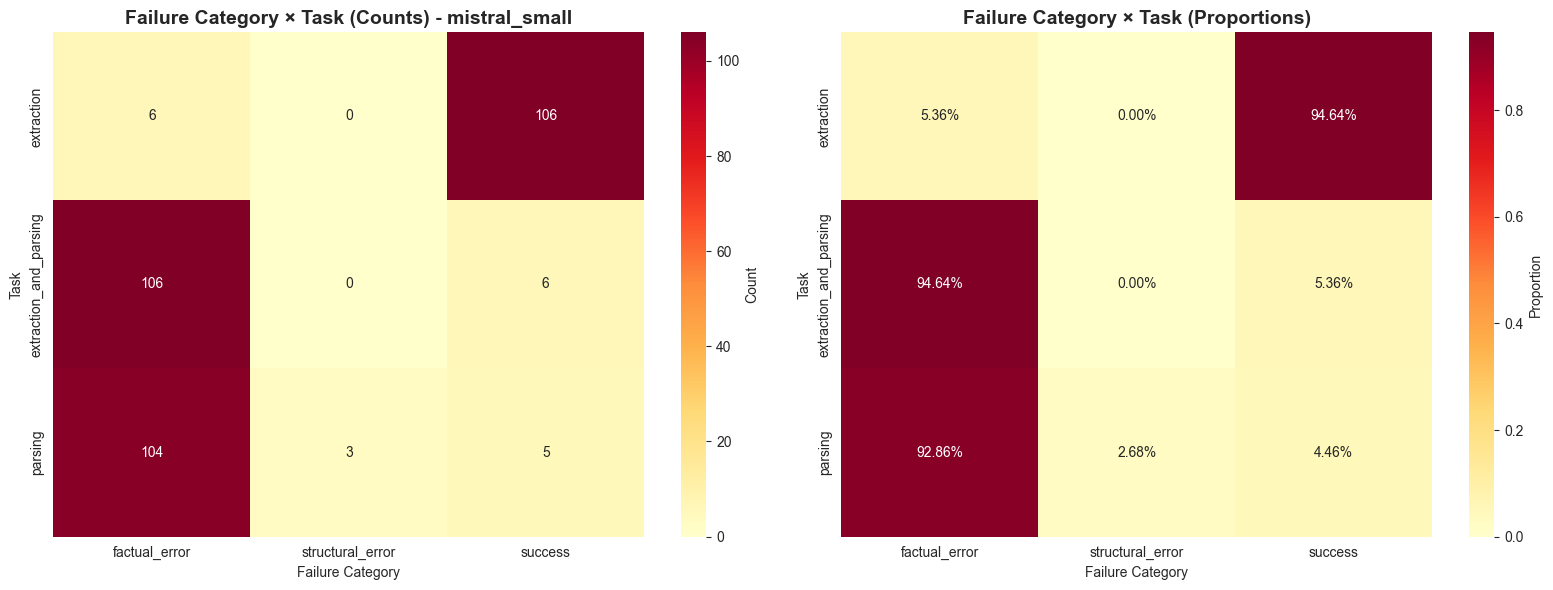

In [8]:
# Create pivot table for heatmap
heatmap_data = detailed.groupby(['task', 'failure_category']).size().unstack(fill_value=0)

# Normalize by row to show proportions
heatmap_data_norm = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: Counts
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    ax=ax1,
    cbar_kws={'label': 'Count'}
)
ax1.set_title(f'Failure Category × Task (Counts) - {primary_model}', fontsize=14, fontweight='bold')
ax1.set_xlabel('Failure Category')
ax1.set_ylabel('Task')

# Heatmap: Proportions
sns.heatmap(
    heatmap_data_norm,
    annot=True,
    fmt='.2%',
    cmap='YlOrRd',
    ax=ax2,
    cbar_kws={'label': 'Proportion'}
)
ax2.set_title('Failure Category × Task (Proportions)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Failure Category')
ax2.set_ylabel('Task')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / primary_model / 'heatmap_failure_task.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Reference Count Analysis

Analyze the relationship between reference count and failure likelihood.

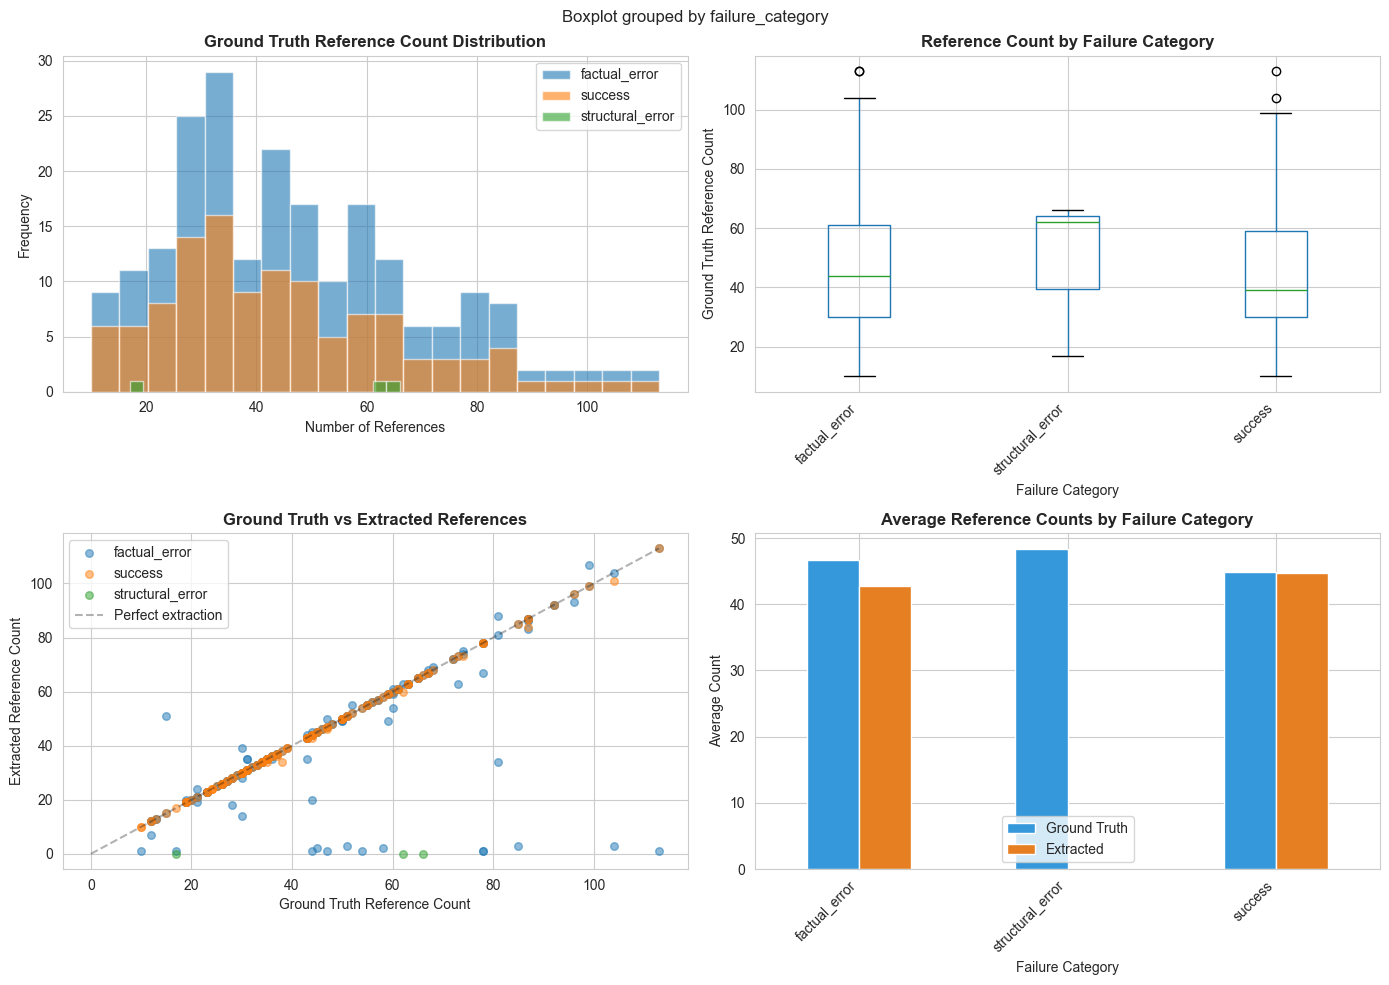


Reference Count Statistics by Failure Category:
                 gt_ref_count                                                \
                        count       mean        std   min   25%   50%   75%   
failure_category                                                              
factual_error           216.0  46.708333  22.427208  10.0  30.0  44.0  61.0   
structural_error          3.0  48.333333  27.209067  17.0  39.5  62.0  64.0   
success                 117.0  44.863248  21.905717  10.0  30.0  39.0  59.0   

                        extracted_ref_count                              \
                    max               count       mean        std   min   
failure_category                                                          
factual_error     113.0               216.0  42.814815  23.376851   1.0   
structural_error   66.0                 3.0   0.000000   0.000000   0.0   
success           113.0               117.0  44.717949  21.786126  10.0   

                         

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of ground truth reference counts by failure category
ax1 = axes[0, 0]
for category in detailed['failure_category'].unique():
    cat_data = detailed[detailed['failure_category'] == category]['gt_ref_count']
    ax1.hist(cat_data, alpha=0.6, label=category, bins=20)
ax1.set_title('Ground Truth Reference Count Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of References')
ax1.set_ylabel('Frequency')
ax1.legend()

# Box plot: Reference count by failure category
ax2 = axes[0, 1]
detailed.boxplot(
    column='gt_ref_count',
    by='failure_category',
    ax=ax2
)
ax2.set_title('Reference Count by Failure Category', fontsize=12, fontweight='bold')
ax2.set_xlabel('Failure Category')
ax2.set_ylabel('Ground Truth Reference Count')
plt.sca(ax2)
plt.xticks(rotation=45, ha='right')

# Scatter: GT refs vs Extracted refs
ax3 = axes[1, 0]
for category in detailed['failure_category'].unique():
    cat_data = detailed[detailed['failure_category'] == category]
    ax3.scatter(
        cat_data['gt_ref_count'],
        cat_data['extracted_ref_count'],
        alpha=0.5,
        label=category,
        s=30
    )
# Add diagonal line
max_refs = max(detailed['gt_ref_count'].max(), detailed['extracted_ref_count'].max())
ax3.plot([0, max_refs], [0, max_refs], 'k--', alpha=0.3, label='Perfect extraction')
ax3.set_title('Ground Truth vs Extracted References', fontsize=12, fontweight='bold')
ax3.set_xlabel('Ground Truth Reference Count')
ax3.set_ylabel('Extracted Reference Count')
ax3.legend()

# Average reference count by category
ax4 = axes[1, 1]
avg_refs = detailed.groupby('failure_category')[['gt_ref_count', 'extracted_ref_count']].mean()
avg_refs.plot(kind='bar', ax=ax4, color=['#3498db', '#e67e22'])
ax4.set_title('Average Reference Counts by Failure Category', fontsize=12, fontweight='bold')
ax4.set_xlabel('Failure Category')
ax4.set_ylabel('Average Count')
ax4.legend(['Ground Truth', 'Extracted'])
plt.sca(ax4)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / primary_model / 'reference_count_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nReference Count Statistics by Failure Category:")
print(detailed.groupby('failure_category')[['gt_ref_count', 'extracted_ref_count']].describe())

## 9. Model Comparison (Multiple Models)

If multiple models are loaded, compare their performance.

In [10]:
if len(models_data) > 1:
    print("Comparing multiple models...\n")
    
    # Collect overall metrics for each model
    comparison_data = []
    
    for model_name, data in models_data.items():
        overall = data['overall']
        metrics = {row['metric']: row['value'] for _, row in overall.iterrows()}
        metrics['model'] = model_name
        comparison_data.append(metrics)
    
    comparison_df = pd.DataFrame(comparison_data)
    comparison_df = comparison_df.set_index('model')
    
    # Plot comparison
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Success rates
    ax1 = axes[0, 0]
    comparison_df['success_rate'].plot(kind='bar', ax=ax1, color='#3498db')
    ax1.set_title('Success Rate Comparison', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Success Rate')
    ax1.set_ylim([0, 1])
    plt.sca(ax1)
    plt.xticks(rotation=45, ha='right')
    
    # Failure category rates
    ax2 = axes[0, 1]
    comparison_df[['structural_error_rate', 'refusal_rate', 'factual_error_rate']].plot(
        kind='bar',
        ax=ax2,
        color=['#e74c3c', '#f39c12', '#e67e22']
    )
    ax2.set_title('Failure Category Rates', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Rate')
    ax2.legend(['Structural', 'Refusal', 'Factual'])
    plt.sca(ax2)
    plt.xticks(rotation=45, ha='right')
    
    # Misclassifications vs Hallucinations
    ax3 = axes[1, 0]
    comparison_df[['total_misclassifications', 'total_hallucinations']].plot(
        kind='bar',
        ax=ax3,
        color=['#e67e22', '#e74c3c']
    )
    ax3.set_title('Factual Errors: Misclassifications vs Hallucinations', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Count')
    ax3.legend(['Misclassifications', 'Hallucinations'])
    plt.sca(ax3)
    plt.xticks(rotation=45, ha='right')
    
    # Reference extraction accuracy
    ax4 = axes[1, 1]
    comparison_df[['avg_gt_ref_count', 'avg_extracted_ref_count']].plot(
        kind='bar',
        ax=ax4,
        color=['#3498db', '#e67e22']
    )
    ax4.set_title('Average Reference Counts', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Count')
    ax4.legend(['Ground Truth', 'Extracted'])
    plt.sca(ax4)
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nModel Comparison Summary:")
    print(comparison_df[['success_rate', 'structural_error_rate', 'factual_error_rate', 'refusal_rate']])
else:
    print("Only one model loaded. Add more models to MODEL_NAMES to enable comparison.")

Only one model loaded. Add more models to MODEL_NAMES to enable comparison.


## 10. Detailed Failure Inspection

Explore specific failure cases interactively.

In [11]:
# Filter and examine specific failure cases

# Example: View all structural errors
structural_errors = detailed[detailed['has_structural_error'] == True]
print(f"Structural Errors ({len(structural_errors)} total):")
print(structural_errors[['file_id', 'document_category', 'task', 'structural_error_type']].head(10))
print("\n" + "="*80 + "\n")

# Example: View factual errors with high major error counts
high_major_errors = detailed[
    (detailed['has_factual_error'] == True) & 
    (detailed['major_error_count'] > 5)
].sort_values('major_error_count', ascending=False)

print(f"High Major Error Cases ({len(high_major_errors)} total):")
print(high_major_errors[[
    'file_id', 'document_category', 'task', 
    'gt_ref_count', 'extracted_ref_count', 
    'major_error_count', 'minor_error_count'
]].head(10))
print("\n" + "="*80 + "\n")

# Example: View refusals
refusals = detailed[detailed['has_refusal'] == True]
print(f"Refusal Cases ({len(refusals)} total):")
print(refusals[['file_id', 'document_category', 'task']].head(10))

Structural Errors (3 total):
         file_id document_category     task  structural_error_type
57        ENE_47               ENE  parsing  empty_references_list
80   SOC-SCI_104           SOC-SCI  parsing  empty_references_list
103      CHEM_21              CHEM  parsing  empty_references_list


High Hallucination Cases (18 total):
            file_id document_category                    task  gt_ref_count  \
321      HEA-PRO_60           HEA-PRO  extraction_and_parsing            15   
244   AGR-BIO-SCI_1       AGR-BIO-SCI  extraction_and_parsing            34   
322  BIO-GEN-MOL_12       BIO-GEN-MOL  extraction_and_parsing            68   
27    AGR-BIO-SCI_1       AGR-BIO-SCI                 parsing            34   
62   BUS-MAN-ACC_14       BUS-MAN-ACC                 parsing            85   
94   BIO-GEN-MOL_12       BIO-GEN-MOL                 parsing            68   
325      IMM-MIC_62           IMM-MIC  extraction_and_parsing            52   
327      HEA-PRO_58           HE

## 11. Export Summary Report

Generate a text summary of key findings.

In [12]:
report_lines = []
report_lines.append(f"# Error Analysis Report: {primary_model}")
report_lines.append(f"\n## Overall Statistics\n")

overall = primary_data['overall']
for _, row in overall.iterrows():
    metric = row['metric']
    value = row['value']
    if 'rate' in metric:
        report_lines.append(f"- {metric}: {value:.2%}")
    elif 'count' in metric or 'total' in metric:
        report_lines.append(f"- {metric}: {int(value)}")
    else:
        report_lines.append(f"- {metric}: {value:.2f}")

report_lines.append("\n## Key Findings\n")

# Most problematic categories
worst_categories = primary_data['by_category'].nsmallest(5, 'success_rate')
report_lines.append("### Most Problematic Document Categories:")
for _, row in worst_categories.iterrows():
    report_lines.append(
        f"- {row['document_category']}: {row['success_rate']:.1%} success rate "
        f"({row['total_documents']} documents)"
    )

# Task performance
report_lines.append("\n### Task Performance:")
for _, row in primary_data['by_task'].iterrows():
    report_lines.append(
        f"- {row['task']}: {row['success_rate']:.1%} success rate "
        f"({row['total_documents']} documents)"
    )

# Factual error analysis
if len(factual_errors) > 0:
    report_lines.append("\n### Factual Error Analysis:")
    report_lines.append(f"- Documents with factual errors: {len(factual_errors)}")
    report_lines.append(f"- Total misclassifications: {int(total_misclass)}")
    report_lines.append(f"- Total hallucinations: {int(total_halluc)}")
    report_lines.append(f"- Hallucination rate: {total_halluc / (total_misclass + total_halluc):.1%}")

report_text = "\n".join(report_lines)

# Save report
report_path = OUTPUT_DIR / primary_model / 'analysis_report.txt'
with open(report_path, 'w') as f:
    f.write(report_text)

print(report_text)
print(f"\n\nReport saved to: {report_path}")

# Error Analysis Report: mistral_small

## Overall Statistics

- total_documents: 336
- success_count: 117
- success_rate: 34.82%
- structural_error_count: 3
- structural_error_rate: 0.89%
- refusal_count: 0
- refusal_rate: 0.00%
- factual_error_count: 216
- factual_error_rate: 64.29%
- total_misclassifications: 2941
- total_hallucinations: 387
- total_correct_refs: 11152
- avg_gt_ref_count: 46
- avg_extracted_ref_count: 43

## Key Findings

### Most Problematic Document Categories:
- COM-SCI: 25.0% success rate (12 documents)
- ENE: 25.0% success rate (12 documents)
- ENG: 25.0% success rate (12 documents)
- PSY: 25.0% success rate (12 documents)
- z_notes_test: 25.0% success rate (12 documents)

### Task Performance:
- parsing: 4.5% success rate (112 documents)
- extraction: 94.6% success rate (112 documents)
- extraction_and_parsing: 5.4% success rate (112 documents)

### Factual Error Analysis:
- Documents with factual errors: 216
- Total misclassifications: 2941
- Total hallucinat

## Summary

This notebook provides comprehensive visualization and analysis of LLM errors in the CEX benchmark.

**Next Steps:**
1. Analyze specific failure cases in detail
2. Compare with other models by adding them to `MODEL_NAMES`
3. Investigate patterns in specific document categories or tasks
4. Use findings to improve prompts or model selection

## Summary of Multi-Model Analysis

All visualizations have been saved to `outputs/cex/multi_model_comparison/`:
- `reference_level_comparison.png` - Reference-level failure distribution across all models
- `category_performance.png` - Performance by document category heatmap  
- `document_distribution.png` - Document-level failure category distribution

### Key Insights:

1. **Visualization 1** shows which models have the highest correct reference count and how they compare in terms of structural errors vs factual errors (misclassifications and hallucinations).

2. **Visualization 2** reveals whether certain categories (e.g., MATH, CHEM) are consistently harder across all models and if GROBID excels in specific domains.

3. **Visualization 3** displays the proportion of perfectly parsed documents (success) vs partially correct (factual_error) vs structural failures for each model.